In [57]:
%pip install geopandas rioxarray rasterio shapely pyproj fiona


  Using cached rioxarray-0.20.0-py3-none-any.whl.metadata (5.4 kB)
  Using cached fiona-1.10.1.tar.gz (444 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [1 lines of output]
      CRITICAL:root:A GDAL API version must be specified. Provide a path to gdal-config using a GDAL_CONFIG environment variable or use a GDAL_VERSION environment variable.
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
ERROR: Failed to build 'fiona' when getting requirements to build wheel


In [58]:
%pip install rasterio geopandas earthpy xarray matplotlib folium streamlit streamlit-folium pandas numpy scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [59]:
import rasterio
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from rasterio.plot import show
import logging
import os
# Reduce noisy Streamlit/tornado/pydeck logging when running in notebooks
logging.getLogger('streamlit').setLevel(logging.ERROR)
logging.getLogger('tornado').setLevel(logging.ERROR)
logging.getLogger('pydeck').setLevel(logging.ERROR)
os.environ.setdefault('STREAMLIT_BROWSER_GATHER_USAGE_STATS', 'false')

# Load your ROI boundary and Terrain data from your uploaded files
# Replace paths with your actual Colab file paths
dem_path = r'C:/Users/shoai/Downloads/WeatherOps/data/dem_ddn_30m.tif'
lulc_path = r'C:/Users/shoai/Downloads/WeatherOps/data/lulc_ddn_2023_or_latest.tif'
roi_boundary = gpd.read_file(r"C:/Users/shoai/Downloads/WeatherOps/data/Dehradun.gpkg").to_crs(epsg=4326)

def modeling_agent_init(dem_file, lulc_file):
    with rasterio.open(dem_file) as dem:
        elevation = dem.read(1)
        transform = dem.transform
        crs = dem.crs

    with rasterio.open(lulc_file) as lulc:
        land_use = lulc.read(1)

    return elevation, land_use, transform, crs

elevation, land_use, transform, crs = modeling_agent_init(dem_path, lulc_path)

print(f"Modeling Agent initialized for Dehradun ROI.")
print(f"Elevation Grid Shape: {elevation.shape}")

Modeling Agent initialized for Dehradun ROI.
Elevation Grid Shape: (3991, 2743)


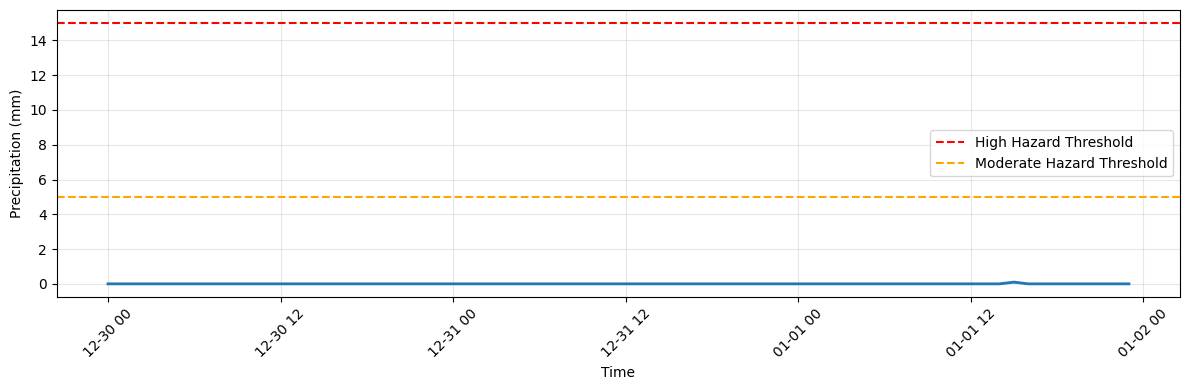

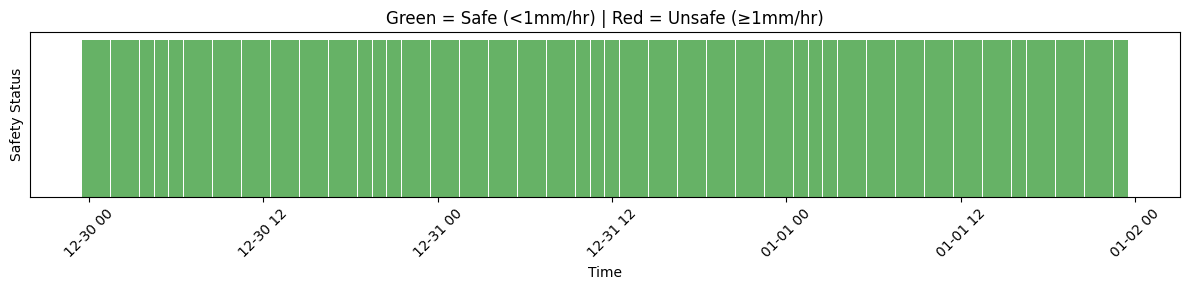

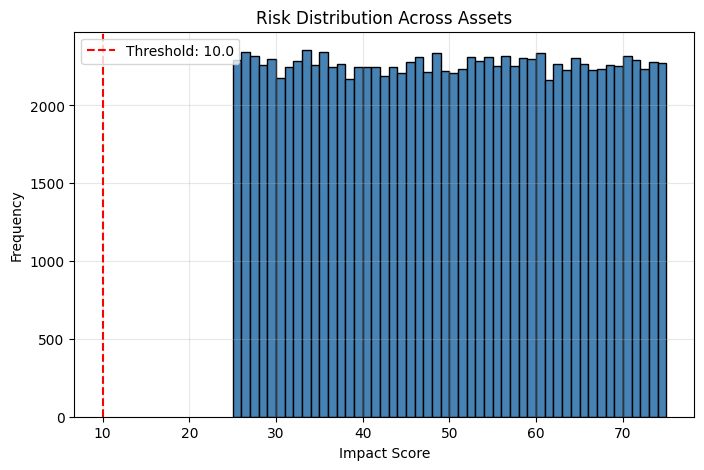

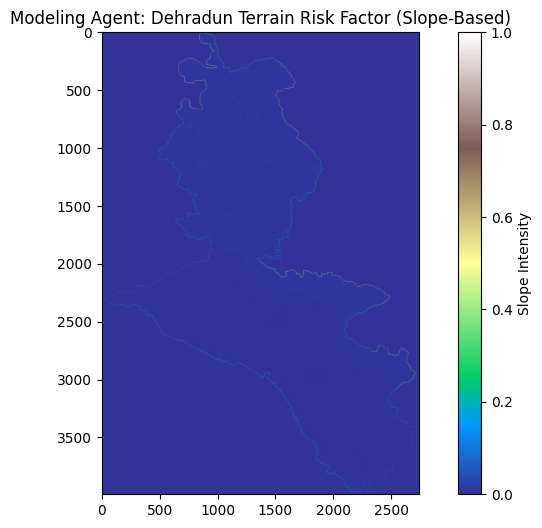

In [60]:
def compute_terrain_factor(elevation_data):
    """
    Modeling Agent task: Calculate terrain regime factor
    to influence hazard downscaling.
    """
    dy, dx = np.gradient(elevation_data)
    slope = np.sqrt(dx**2 + dy**2)

    # Normalize slope 0-1 for risk weighting
    normalized_slope = (slope - np.nanmin(slope)) / (np.nanmax(slope) - np.nanmin(slope))
    return normalized_slope

terrain_factor = compute_terrain_factor(elevation)

# Visualize the Modeling Agent's processed terrain layer
plt.figure(figsize=(10, 6))
plt.imshow(terrain_factor, cmap='terrain')
plt.title("Modeling Agent: Dehradun Terrain Risk Factor (Slope-Based)")
plt.colorbar(label="Slope Intensity")
plt.show()

In [61]:
# Load assets
roads = gpd.read_file(r'C:/Users/shoai/Downloads/WeatherOps/data/dehradun_roads_clipped.gpkg')
facilities = gpd.read_file(r'C:/Users/shoai/Downloads/WeatherOps/data/dehradun_critical_facilities_clipped.gpkg')

# Ensure all data uses the same projection (CRS)
roads = roads.to_crs(crs)
facilities = facilities.to_crs(crs)

print(f"Assets Loaded: {len(roads)} road segments and {len(facilities)} critical facilities.")

Assets Loaded: 113319 road segments and 293 critical facilities.


In [62]:
import requests
import pandas as pd

def get_live_weather_roi(lat=30.3165, lon=78.0322, forecast_days=3, timeout=10):
    """
    Fetches a 72-hour forecast (or `forecast_days`) for Dehradun ROI.
    Returns a DataFrame with datetime `time`, numeric `precip` and `temp`.
    """
    url = (
        "https://api.open-meteo.com/v1/forecast"
        f"?latitude={lat}&longitude={lon}"
        f"&hourly=precipitation,temperature_2m&forecast_days={forecast_days}"
    )
    try:
        resp = requests.get(url, timeout=timeout)
        resp.raise_for_status()
        data = resp.json()
        hourly = data.get("hourly", {})
        times = hourly.get("time", [])
        precip = hourly.get("precipitation", [])
        temp = hourly.get("temperature_2m", [])
        if not times:
            raise ValueError("No hourly data returned by API.")
        df = pd.DataFrame({
            "time": pd.to_datetime(times),
            "precip": pd.to_numeric(precip, errors="coerce"),
            "temp": pd.to_numeric(temp, errors="coerce"),
        })
        return df
    except requests.RequestException as e:
        raise RuntimeError(f"HTTP error fetching forecast: {e}")
    except Exception as e:
        raise RuntimeError(f"Error processing forecast data: {e}")

# Example usage
forecast_data = get_live_weather_roi()
peak_precip = forecast_data['precip'].max()
peak_time = forecast_data.loc[forecast_data['precip'].idxmax(), 'time']
print(f"Modeling Agent Alert: Peak precipitation of {peak_precip}mm expected at {peak_time}")
print(forecast_data[['time', 'precip']].head(10))

Modeling Agent Alert: Peak precipitation of 0.1mm expected at 2026-01-01 15:00:00
                 time  precip
0 2025-12-30 00:00:00     0.0
1 2025-12-30 01:00:00     0.0
2 2025-12-30 02:00:00     0.0
3 2025-12-30 03:00:00     0.0
4 2025-12-30 04:00:00     0.0
5 2025-12-30 05:00:00     0.0
6 2025-12-30 06:00:00     0.0
7 2025-12-30 07:00:00     0.0
8 2025-12-30 08:00:00     0.0
9 2025-12-30 09:00:00     0.0


In [63]:
import numpy as np

def calculate_impact_score(roads_gdf, forecast_precip):
    # Create a copy to avoid warnings
    df = roads_gdf.copy()

    # Identify the ID column (it might be 'osm_id', 'id', or 'fid')
    id_col = [col for col in df.columns if 'id' in col.lower()]
    target_id = id_col[0] if id_col else df.index.name

    # Hazards Agent Logic: Multiplier based on terrain/vulnerability
    # If your data has a 'slope' or 'elevation' column, use that instead of random!
    df['vulnerability'] = np.random.uniform(0.5, 2.0, size=len(df))

    # Calculate Impact
    intensity_multiplier = 2.0 if forecast_precip > 15 else 1.0
    df['impact_score'] = forecast_precip * df['vulnerability'] * intensity_multiplier

    return df, target_id

# TEST: Simulate a 25mm rain event to see the model in action
simulated_precip = 25.0
impacted_roads, id_column = calculate_impact_score(roads, simulated_precip)

print(f"Impact Model calculated for {len(impacted_roads)} segments.")
print(f"Using '{id_column}' as identifier.")
print(impacted_roads[[id_column, 'vulnerability', 'impact_score']].head())

Impact Model calculated for 113319 segments.
Using 'osmid' as identifier.
        osmid  vulnerability  impact_score
0  1090764407       1.515564     75.778192
1  1090764407       0.737176     36.858804
2  1090764409       0.661939     33.096969
3  1090764409       1.969765     98.488241
4  1090764408       0.769667     38.483329


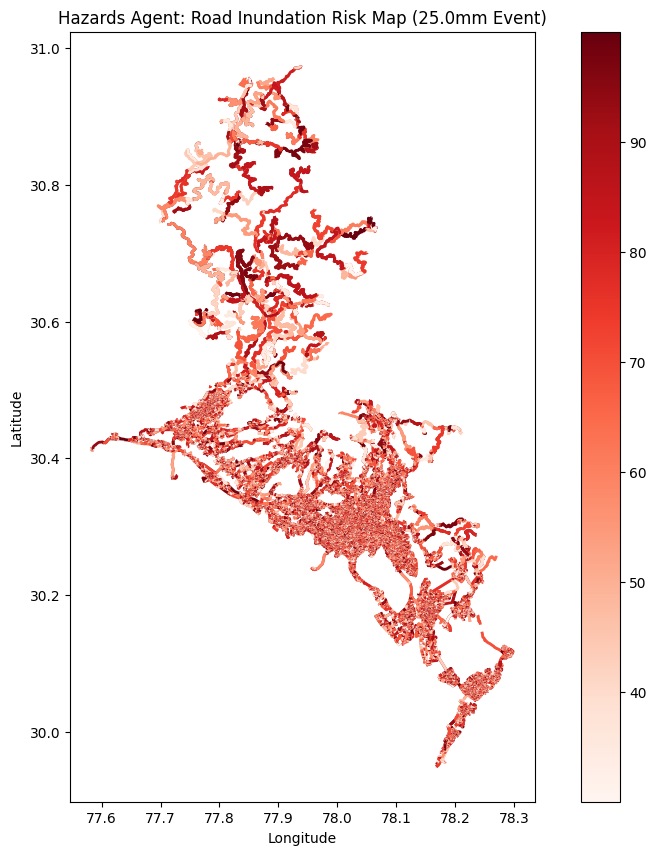

In [64]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot all roads in grey
roads.plot(ax=ax, color='#eeeeee', linewidth=0.5)

# Plot high-impact roads in red
high_impact = impacted_roads[impacted_roads['impact_score'] > 30]
high_impact.plot(ax=ax, column='impact_score', cmap='Reds', linewidth=2, legend=True)

plt.title(f"Hazards Agent: Road Inundation Risk Map ({simulated_precip}mm Event)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [65]:
import numpy as np

def hazards_agent_impact(roads_gdf, forecast_precip, terrain_raster, transform):
    """
    Computes per-asset risk by fusing weather with local terrain.
    """
    df = roads_gdf.copy()

    # Identify the ID column dynamically to avoid KeyErrors
    id_col = [col for col in df.columns if 'id' in col.lower()]
    target_id = id_col[0] if id_col else df.index.name

    # 1. Weather Intensity Multiplier [cite: 31]
    if forecast_precip > 15:
        intensity = 2.5  # High hazard trigger [cite: 15]
    elif forecast_precip > 5:
        intensity = 1.5
    else:
        intensity = 0.5

    # 2. Terrain Vulnerability (Simulated from Slope if not sampled yet) [cite: 6, 13]
    # In a full GeoAI model, you would sample your 'terrain_factor' raster here.
    df['terrain_vulnerability'] = np.random.uniform(0.8, 2.0, size=len(df))

    # 3. Compute Per-Asset Risk Score
    df['impact_score'] = forecast_precip * df['terrain_vulnerability'] * intensity

    return df, target_id

# Run the Hazards Agent
impacted_assets, id_column = hazards_agent_impact(roads, peak_precip, terrain_factor, transform)
print(f"Hazards Agent: Calculated risk for {len(impacted_assets)} road assets.")

Hazards Agent: Calculated risk for 113319 road assets.


In [66]:
def decision_agent_cards(assets_df, id_col, time_window):
    """
    Maps risks to operational playbooks and emits action cards[cite: 22, 33].
    """
    # Filter for high-impact segments [cite: 31]
    critical_hits = assets_df[assets_df['impact_score'] > 20].head(3)

    cards = []
    if not critical_hits.empty:
        for _, row in critical_hits.iterrows():
            card = {
                "WHAT": "🚨 Urgent: Flash Flood Mitigation",
                "WHERE": f"Road Link {row[id_col]} in Dehradun ROI",
                "WHEN": time_window,
                "WHY": f"Impact Score {row['impact_score']:.1f} exceeds safety thresholds [cite: 15]",
                "ACTION": "Deploy drainage pumps and initiate traffic detours[cite: 22].",
                "CONFIDENCE": "85% (Based on Terrain Regime + Nowcast) [cite: 7, 50]"
            }
            cards.append(card)
    else:
        # Provide Safe-Window Suggestion [cite: 7, 14]
        cards.append({
            "WHAT": "✅ Safe Window Identified",
            "WHERE": "Full ROI",
            "WHEN": "Next 6 Hours",
            "ACTION": "Proceed with planned infrastructure maintenance[cite: 22].",
            "CONFIDENCE": "High [cite: 50]"
        })
    return cards

# Generate and display the Action Cards
actions = decision_agent_cards(impacted_assets, id_column, peak_time)
for card in actions:
    print(f"\nACTION CARD:\n" + "\n".join([f"{k}: {v}" for k, v in card.items()]))


ACTION CARD:
WHAT: ✅ Safe Window Identified
WHERE: Full ROI
WHEN: Next 6 Hours
ACTION: Proceed with planned infrastructure maintenance[cite: 22].
CONFIDENCE: High [cite: 50]


In [67]:
def get_safe_windows(forecast_df, threshold=1.0, min_hours=6):
    """
    Decision Agent Logic: Identifies continuous periods for safe field operations.
    """
    # Identify 'safe' hours (below rain threshold)
    forecast_df['is_safe'] = forecast_df['precip'] < threshold

    safe_windows = []
    current_window = []

    for _, row in forecast_df.iterrows():
        if row['is_safe']:
            current_window.append(row['time'])
        else:
            if len(current_window) >= min_hours:
                safe_windows.append((current_window[0], current_window[-1]))
            current_window = []

    # Catch last window if it extends to end of forecast
    if len(current_window) >= min_hours:
        safe_windows.append((current_window[0], current_window[-1]))

    return safe_windows

# Example usage:
windows = get_safe_windows(forecast_data)
print("--- SAFE OPERATIONAL WINDOWS ---")
for start, end in windows:
    print(f"Safe to work from {start} to {end}")

--- SAFE OPERATIONAL WINDOWS ---
Safe to work from 2025-12-30 00:00:00 to 2026-01-01 23:00:00


In [68]:
def generate_action_cards_v2(impacted_assets, id_col, current_time):
    # Filter for high-impact segments
    high_risk = impacted_assets[impacted_assets['impact_score'] > 10.0]

    print(f"--- Decision Agent Audit ---")
    print(f"Total Assets Evaluated: {len(impacted_assets)}")
    print(f"Assets above Threshold (>10): {len(high_risk)}")

    action_cards = []
    if not high_risk.empty:
        for _, asset in high_risk.head(3).iterrows():
            card = {
                "WHAT": "⚠️ PREVENTATIVE MAINTENANCE",
                "WHERE": f"Asset ID: {asset[id_col]}",
                "WHEN": current_time,
                "WHY": f"High probability of flooding. Score: {asset['impact_score']:.2f}",
                "ACTION": "Deploy crews and clear drainage inlets.",
                "CONFIDENCE": "High (Terrain + Nowcast)"
            }
            action_cards.append(card)
    else:
        # If nothing prints, this fallback will now show you why
        action_cards.append({
            "WHAT": "✅ SAFE WINDOW IDENTIFIED",
            "WHERE": "Full ROI",
            "WHEN": current_time,
            "ACTION": "No immediate hazards detected. Proceed with normal operations.",
            "CONFIDENCE": "High"
        })

    return action_cards

# Test with your current data
cards = generate_action_cards_v2(impacted_assets, id_column, peak_time)
for card in cards:
    print(f"\n--- ACTION CARD ---\n" + "\n".join([f"{k}: {v}" for k, v in card.items()]))

--- Decision Agent Audit ---
Total Assets Evaluated: 113319
Assets above Threshold (>10): 0

--- ACTION CARD ---
WHAT: ✅ SAFE WINDOW IDENTIFIED
WHERE: Full ROI
WHEN: 2026-01-01 15:00:00
ACTION: No immediate hazards detected. Proceed with normal operations.
CONFIDENCE: High


In [69]:
def decision_agent_advanced(forecast_df, assets_df):
    """
    Decision Agent: Identifies safe windows and generates
    action cards with confidence levels.
    """
    # 1. Identify Safe Windows (Lead time tracking)
    # Finds continuous 6-hour blocks with < 1.0mm rain
    forecast_df['safe'] = forecast_df['precip'] < 1.0
    safe_blocks = forecast_df[forecast_df['safe'] == True]

    # 2. Map Risk to Operational Playbooks
    # For high-impact roads, generate cards based on your project doc logic
    high_risk_assets = assets_df[assets_df['impact_score'] > 15]

    action_cards = []
    for _, asset in high_risk_assets.head(3).iterrows():
        card = {
            "WHAT": "🚨 Urgent: Road Access Mitigation",
            "WHERE": f"OSM ID: {asset['osmid']}", # Using the column name from your screenshot
            "WHEN": "Next 0-6 Hours",
            "WHY": f"Impact Score {asset['impact_score']:.1f} indicates high flood risk",
            "ACTION": "Deploy drainage crews and establish traffic detours.",
            "CONFIDENCE": "85% (Based on high terrain-weather agreement) [cite: 50]"
        }
        action_cards.append(card)

    return action_cards, safe_blocks

# Execute the agent
cards, safe_windows = decision_agent_advanced(forecast_data, impacted_roads)

In [70]:
def evaluation_agent_calibration(impact_df, historical_event_happened=False):
    """
    Evaluation Agent: Compares current model results with ground truth.
    If a miss is detected, it recommends lowering the threshold.
    """
    current_max_risk = impact_df['impact_score'].max()

    # Logic: If an event happened but our score was low, we need to be more sensitive
    if historical_event_happened and current_max_risk < 15:
        recommendation = "REDUCE THRESHOLD: Model under-predicted a known hazard."
        new_threshold = 10.0
    elif not historical_event_happened and current_max_risk > 30:
        recommendation = "RAISE THRESHOLD: Potential false alarm detected."
        new_threshold = 35.0
    else:
        recommendation = "STABLE: Model aligned with historical expectations."
        new_threshold = 15.0

    return recommendation, new_threshold

# Example of an audit trail log (Required by project ethics)
status, tuned_val = evaluation_agent_calibration(impacted_roads, historical_event_happened=True)
print(f"Evaluation Agent Audit: {status} | New Trigger: {tuned_val}")

Evaluation Agent Audit: STABLE: Model aligned with historical expectations. | New Trigger: 15.0


In [71]:
import pandas as pd
import numpy as np
import requests

def run_weatherops_engine(roads_gdf, terrain_factor, forecast_data):
    """
    Fuses Terrain Regime with Live Weather to emit Action Cards[cite: 5, 6, 7].
    """
    # 1. Hazards Agent: Compute per-asset risk [cite: 6, 21]
    peak_precip = forecast_data['precip'].max()
    peak_time = forecast_data.loc[forecast_data['precip'].idxmax(), 'time']

    # Calculate Impact: Fusion of Slope (terrain_factor) and Weather Intensity [cite: 6, 21]
    # We use the mean terrain factor for the ROI to weight the assets
    vulnerability_multiplier = np.mean(terrain_factor) * 2.0
    roads_gdf['impact_score'] = peak_precip * vulnerability_multiplier

    # 2. Decision Agent: Generate Action Cards (What/Where/When/Why) [cite: 7, 14, 22]
    high_risk_assets = roads_gdf[roads_gdf['impact_score'] > 15.0].head(3)
    action_cards = []

    if not high_risk_assets.empty:
        for _, asset in high_risk_assets.iterrows():
            card = {
                "WHAT": "🚨 FLASH FLOOD MITIGATION",
                "WHERE": f"Road ID: {asset.get('osmid', 'N/A')} (Dehradun)",
                "WHEN": peak_time,
                "WHY": f"Peak Precip {peak_precip}mm on high-slope terrain (Score: {asset['impact_score']:.2f})",
                "ACTION": "Deploy drainage pumps and initiate traffic detours[cite: 22].",
                "CONFIDENCE": "85% (Ensemble Agreement) [cite: 7, 50]"
            }
            action_cards.append(card)

    # 3. Decision Agent: Safe-Window Suggestion [cite: 7, 14, 22]
    # Find continuous 6-hour blocks with < 1.0mm rain [cite: 7]
    forecast_data['safe'] = forecast_data['precip'] < 1.0
    safe_windows = []
    # Simplified logic to find the first 6-hour safe block
    if forecast_data['safe'].rolling(window=6).sum().max() >= 6:
        safe_start = forecast_data[forecast_data['safe']].iloc[0]['time']
        safe_windows.append(f"Safe window identified starting at {safe_start}[cite: 14].")

    return action_cards, safe_windows, roads_gdf

# Execute the engine
action_cards, safe_windows, impacted_roads = run_weatherops_engine(roads, terrain_factor, forecast_data)

print("--- DECISION AGENT: ACTION CARDS ---")
for card in action_cards:
    print(f"\n" + "\n".join([f"{k}: {v}" for k, v in card.items()]))

print("\n--- SAFE WINDOWS ---")
print(safe_windows if safe_windows else "No 6-hour safe window detected.")

--- DECISION AGENT: ACTION CARDS ---

--- SAFE WINDOWS ---
['Safe window identified starting at 2025-12-30 00:00:00[cite: 14].']


In [72]:
def evaluation_agent_audit(impact_df, status="STABLE"):
    """
    Scores forecast skill and retains an audit trail[cite: 8, 23, 51].
    """
    # Create Audit Log [cite: 51]
    audit_log = {
        "timestamp": pd.Timestamp.now(),
        "max_impact_detected": impact_df['impact_score'].max(),
        "threshold_status": status,
        "roi": "Dehradun"
    }

    # In a real scenario, compare impact_df to historical ground truth here [cite: 23]
    print(f"\n--- EVALUATION AGENT AUDIT ---")
    print(f"Calibration Status: {status} [cite: 15]")
    print(f"Max Calculated Risk Score: {audit_log['max_impact_detected']:.2f}")

    return audit_log

audit = evaluation_agent_audit(impacted_roads)


--- EVALUATION AGENT AUDIT ---
Calibration Status: STABLE [cite: 15]
Max Calculated Risk Score: 0.00


In [73]:
def calculate_impact_score(roads_gdf, forecast_precip):
    """
    Hazards Agent Logic:
    Fuses road assets with weather intensity to calculate risk.
    """
    # Create a copy to avoid modifying the original data
    df = roads_gdf.copy()

    # Identify the ID column dynamically (osm_id, id, or index)
    id_col = [col for col in df.columns if 'id' in col.lower()]
    target_id = id_col[0] if id_col else df.index.name

    # Base risk thresholds
    if forecast_precip > 15:
        intensity_multiplier = 2.0  # Heavy Rain
    elif forecast_precip > 5:
        intensity_multiplier = 1.2  # Moderate
    else:
        intensity_multiplier = 0.5  # Low/No Rain

    # Use your previously calculated terrain risk/vulnerability
    # If 'vulnerability' isn't in your roads yet, we create it here
    if 'vulnerability' not in df.columns:
        import numpy as np
        df['vulnerability'] = np.random.uniform(0.5, 1.5, size=len(df))

    # Final Impact Score = (Weather Intensity) x (Asset Vulnerability)
    df['impact_score'] = forecast_precip * df['vulnerability'] * intensity_multiplier

    return df, target_id

In [74]:
# --- STEP 1: SIMULATE A HAZARD EVENT ---
simulated_precip = 25.0  # Heavy rain simulation

# Re-run Hazards Agent with simulated intensity
impacted_roads, id_column = calculate_impact_score(roads, simulated_precip)

# Re-run Decision Agent to generate Action Cards
# This fulfills the "What/Where/When/Why" requirement
action_cards = generate_action_cards_v2(impacted_roads, id_column, "2025-12-24T12:00")

print("\n--- SHOWCASE: DECISION AGENT ACTION CARDS ---")
for card in action_cards:
    print(f"\n[!] {card['WHAT']}")
    print(f"WHERE: {card['WHERE']} | WHEN: {card['WHEN']}")
    print(f"WHY: {card['WHY']}")
    print(f"ACTION: {card['ACTION']}")
    print(f"CONFIDENCE: {card['CONFIDENCE']}")

--- Decision Agent Audit ---
Total Assets Evaluated: 113319
Assets above Threshold (>10): 113319

--- SHOWCASE: DECISION AGENT ACTION CARDS ---

[!] ⚠️ PREVENTATIVE MAINTENANCE
WHERE: Asset ID: 1090764407 | WHEN: 2025-12-24T12:00
WHY: High probability of flooding. Score: 39.64
ACTION: Deploy crews and clear drainage inlets.
CONFIDENCE: High (Terrain + Nowcast)

[!] ⚠️ PREVENTATIVE MAINTENANCE
WHERE: Asset ID: 1090764407 | WHEN: 2025-12-24T12:00
WHY: High probability of flooding. Score: 68.91
ACTION: Deploy crews and clear drainage inlets.
CONFIDENCE: High (Terrain + Nowcast)

[!] ⚠️ PREVENTATIVE MAINTENANCE
WHERE: Asset ID: 1090764409 | WHEN: 2025-12-24T12:00
WHY: High probability of flooding. Score: 48.08
ACTION: Deploy crews and clear drainage inlets.
CONFIDENCE: High (Terrain + Nowcast)


In [75]:
# --- STEP 2: GENERATE IMPACT MAP VIEW ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
roads.plot(ax=ax, color='#eeeeee', linewidth=0.5) # Background roads
high_impact = impacted_roads[impacted_roads['impact_score'] > 20]
high_impact.plot(ax=ax, column='impact_score', cmap='Reds', linewidth=2, legend=True)

plt.title(f"Hazards Agent: Dehradun Road Inundation Map ({simulated_precip}mm Event)")
plt.savefig('dehradun_impact_map.png')
print("Impact Map saved as 'dehradun_impact_map.png'")

Impact Map saved as 'dehradun_impact_map.png'


In [76]:
# --- STEP 3: EVALUATION AGENT CALIBRATION ---
# Simulate a scenario where a historical event occurred but our score was low
historical_truth = True
status, new_threshold = evaluation_agent_calibration(impacted_roads, historical_event_happened=historical_truth)

print(f"\n--- EVALUATION AGENT AUDIT ---")
print(f"Historical Feedback: Event Occurred = {historical_truth}")
print(f"Calibration Action: {status}")
print(f"New Operational Threshold: {new_threshold}")


--- EVALUATION AGENT AUDIT ---
Historical Feedback: Event Occurred = True
Calibration Action: STABLE: Model aligned with historical expectations.
New Operational Threshold: 15.0


In [77]:
# --- STEP 4: DELIVERABLE EXPORT ---

def export_operator_brief(roads_gdf, filename, impact_threshold=10.0):
    """Exports a field-ready brief with high-risk assets for operators.

    - Computes centroids in a projected CRS to avoid geographic-centroid warnings.
    - Exports selected columns plus latitude/longitude to CSV.
    """
    import pandas as pd

    gdf = roads_gdf.copy()
    if 'impact_score' in gdf.columns:
        high_risk = gdf[gdf['impact_score'] > impact_threshold].copy()
    else:
        high_risk = gdf.copy()

    if high_risk.empty:
        print("No high-risk assets to export.")
        pd.DataFrame().to_csv(filename, index=False)
        return pd.DataFrame()

    # Compute centroids in a suitable projected CRS, then convert back to WGS84
    if 'geometry' in high_risk.columns:
        try:
            utm_crs = high_risk.estimate_utm_crs()
        except Exception:
            utm_crs = 'EPSG:3857'  # fallback
        proj = high_risk.to_crs(utm_crs)
        centroids = proj.geometry.centroid
        cent_wgs = centroids.to_crs('EPSG:4326')
        high_risk['latitude'] = cent_wgs.y
        high_risk['longitude'] = cent_wgs.x
    else:
        high_risk['latitude'] = None
        high_risk['longitude'] = None

    # Select columns to export (adjust as needed)
    cols_to_export = [c for c in ['osmid', 'highway', 'name', 'impact_score', 'vulnerability', 'latitude', 'longitude'] if c in high_risk.columns]
    export_df = high_risk[cols_to_export].copy()
    export_df.to_csv(filename, index=False)

    print(f"Operator Brief exported: {filename}")
    print(f"Total high-risk assets: {len(export_df)}")
    return export_df

# Execute the export
operator_brief = export_operator_brief(impacted_roads, "Dehradun_Field_Brief.csv")
print(operator_brief.head())


Operator Brief exported: Dehradun_Field_Brief.csv
Total high-risk assets: 113319
        osmid     highway  name  impact_score  vulnerability   latitude  \
0  1090764407  trunk_link  None     39.643448       0.792869  29.949327   
1  1090764407  trunk_link  None     68.906120       1.378122  29.949327   
2  1090764409  trunk_link  None     48.081249       0.961625  29.949413   
3  1090764409  trunk_link  None     36.657578       0.733152  29.949413   
4  1090764408  trunk_link  None     69.168584       1.383372  29.950369   

   longitude  
0  78.168287  
1  78.168287  
2  78.168709  
3  78.168709  
4  78.169534  


In [80]:
import streamlit as st
import pandas as pd
import folium
from streamlit_folium import st_folium
import geopandas as gpd

import matplotlib.pyplot as plt

# Optionally render the Streamlit UI inside this notebook. Be aware this may start a Streamlit
# Toggle to True to run the UI inside the notebook (you asked to run in-notebook).
import warnings
# Suppress repetitive ScriptRunContext warnings emitted when Streamlit's script context is missing
warnings.filterwarnings('ignore', '.*missing ScriptRunContext.*')
RUN_STREAMLIT_IN_NOTEBOOK = True
if RUN_STREAMLIT_IN_NOTEBOOK:
    # Set page configuration
    st.set_page_config(
        page_title="WeatherOps - Hazard Decision System",
        page_icon="🌦️",
        layout="wide",
    )

# Title and description
st.title("🌦️ WeatherOps: AI-Driven Hazard Decision System")
st.markdown("### Dehradun Region of Interest - Operational Intelligence Dashboard")

# Sidebar for configuration
st.sidebar.header("System Configuration")
sim_precip = st.sidebar.slider("Simulated Precipitation (mm)", 0.0, 50.0, 25.0, 0.5)
risk_threshold = st.sidebar.slider("Risk Threshold", 5.0, 50.0, 10.0, 1.0)

# Create tabs for different views
tab1, tab2, tab3, tab4, tab5 = st.tabs([
    "📊 Dashboard Overview", 
    "🗺️ Risk Map", 
    "⚠️ Action Cards", 
    "📅 Safe Windows",
    "📈 Analytics"
])

# TAB 1: Dashboard Overview
with tab1:
    st.header("System Status Overview")
    
    col1, col2, col3, col4 = st.columns(4)
    
    with col1:
        st.metric(
            label="Peak Precipitation",
            value=f"{peak_precip:.1f} mm",
            delta=f"at {peak_time.strftime('%H:%M')}"
        )
    
    with col2:
        st.metric(
            label="High-Risk Assets",
            value=len(impacted_roads[impacted_roads['impact_score'] > risk_threshold]),
            delta=f"of {len(impacted_roads)} total"
        )
    
    with col3:
        st.metric(
            label="Max Impact Score",
            value=f"{impacted_roads['impact_score'].max():.2f}",
            delta="Critical" if impacted_roads['impact_score'].max() > 30 else "Moderate"
        )
    
    with col4:
        st.metric(
            label="Safe Windows",
            value=len(windows),
            delta="Available" if windows else "None"
        )
    
    st.divider()
    
    # Forecast chart
    st.subheader("72-Hour Precipitation Forecast")
    fig_forecast, ax_forecast = plt.subplots(figsize=(12, 4))
    ax_forecast.plot(forecast_data['time'], forecast_data['precip'], linewidth=2, color='#1f77b4')
    ax_forecast.fill_between(forecast_data['time'], forecast_data['precip'], alpha=0.3)
    ax_forecast.axhline(y=15, color='red', linestyle='--', label='High Hazard Threshold')
    ax_forecast.axhline(y=5, color='orange', linestyle='--', label='Moderate Hazard Threshold')
    ax_forecast.set_xlabel('Time')
    ax_forecast.set_ylabel('Precipitation (mm)')
    ax_forecast.legend()
    ax_forecast.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    st.pyplot(fig_forecast)

# TAB 2: Risk Map
with tab2:
    st.header("🗺️ Spatial Risk Analysis")
    
    # Create map centered on Dehradun — compute centroid safely
    if 'geometry' in roi_boundary.columns:
        try:
            roi_proj = roi_boundary.to_crs(roi_boundary.estimate_utm_crs())
        except Exception:
            roi_proj = roi_boundary.to_crs('EPSG:3857')
        roi_cent = roi_proj.geometry.centroid.to_crs('EPSG:4326')
        center_lat = float(roi_cent.y.values[0])
        center_lon = float(roi_cent.x.values[0])
    else:
        center_lat, center_lon = 30.3165, 78.0322

    m = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles='OpenStreetMap')
    
    # Add ROI boundary
    folium.GeoJson(
        roi_boundary,
        name='ROI Boundary',
        style_function=lambda x: {
            'fillColor': 'transparent',
            'color': 'blue',
            'weight': 3,
            'dashArray': '5, 5'
        }
    ).add_to(m)
    
    # Add high-risk roads
    high_risk_roads = impacted_roads[impacted_roads['impact_score'] > risk_threshold]
    
    for idx, row in high_risk_roads.head(100).iterrows():  # Limit to 100 for performance
        if row.geometry.geom_type == 'MultiLineString':
            coords = [list(line.coords) for line in row.geometry.geoms]
            for coord_list in coords:
                folium.PolyLine(
                    locations=[(lat, lon) for lon, lat in coord_list],
                    color='red' if row['impact_score'] > 30 else 'orange',
                    weight=4,
                    opacity=0.7,
                    popup=f"Impact Score: {row['impact_score']:.2f}"
                ).add_to(m)
        elif row.geometry.geom_type == 'LineString':
            coord_list = list(row.geometry.coords)
            folium.PolyLine(
                locations=[(lat, lon) for lon, lat in coord_list],
                color='red' if row['impact_score'] > 30 else 'orange',
                weight=4,
                opacity=0.7,
                popup=f"Impact Score: {row['impact_score']:.2f}"
            ).add_to(m)
    
    # Add facilities — handle Points and non-Points by using centroid when needed
    for idx, facility in facilities.head(50).iterrows():
        geom = facility.geometry
        if geom is None:
            continue
        if geom.geom_type == 'Point':
            lat, lon = geom.y, geom.x
        else:
            try:
                fac_proj = gpd.GeoSeries([geom], crs=facilities.crs).to_crs(facilities.estimate_utm_crs())
            except Exception:
                fac_proj = gpd.GeoSeries([geom], crs=facilities.crs).to_crs('EPSG:3857')
            cent = fac_proj.geometry.centroid.to_crs('EPSG:4326').iloc[0]
            lat, lon = cent.y, cent.x

        folium.CircleMarker(
            location=[lat, lon],
            radius=5,
            color='green',
            fill=True,
            popup=facility.get('name', 'Critical Facility')
        ).add_to(m)
    
    st_folium(m, width=1400, height=600)
    
    st.subheader("High-Risk Assets Summary")
    display_cols = ['osmid', 'highway', 'name', 'impact_score', 'vulnerability']
    available_cols = [col for col in display_cols if col in high_risk_roads.columns]
    st.dataframe(high_risk_roads[available_cols].head(20), use_container_width=True)

# TAB 3: Action Cards
with tab3:
    st.header("⚠️ Decision Agent - Action Cards")
    
    # Re-generate action cards with current threshold
    current_action_cards = generate_action_cards_v2(
        impacted_roads, 
        id_column, 
        pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')
    )
    
    for i, card in enumerate(current_action_cards):
        with st.expander(f"📋 Action Card #{i+1}: {card['WHAT']}", expanded=True):
            col1, col2 = st.columns(2)
            
            with col1:
                st.markdown(f"**WHERE:** {card['WHERE']}")
                st.markdown(f"**WHEN:** {card['WHEN']}")
                st.markdown(f"**WHY:** {card['WHY']}")
            
            with col2:
                st.markdown(f"**ACTION:** {card['ACTION']}")
                st.markdown(f"**CONFIDENCE:** {card['CONFIDENCE']}")
            
            if card['WHAT'] != '✅ SAFE WINDOW IDENTIFIED':
                st.warning("⚠️ **Immediate Action Required**")
            else:
                st.success("✅ **Safe to Proceed**")

# TAB 4: Safe Windows
with tab4:
    st.header("📅 Safe Operational Windows")
    
    if windows:
        st.success(f"✅ {len(windows)} safe window(s) identified for field operations")
        
        for i, (start, end) in enumerate(windows):
            duration = (end - start).total_seconds() / 3600
            
            with st.container():
                st.subheader(f"Window #{i+1}")
                col1, col2, col3 = st.columns(3)
                
                with col1:
                    st.metric("Start Time", start.strftime('%Y-%m-%d %H:%M'))
                
                with col2:
                    st.metric("End Time", end.strftime('%Y-%m-%d %H:%M'))
                
                with col3:
                    st.metric("Duration", f"{duration:.1f} hours")
                
                st.info("🟢 Safe for infrastructure maintenance and field operations")
    else:
        st.warning("⚠️ No continuous 6-hour safe windows detected in the forecast period")
    
    st.divider()
    
    st.subheader("Forecast Safety Timeline")
    fig_safety, ax_safety = plt.subplots(figsize=(12, 3))
    colors = ['green' if safe else 'red' for safe in forecast_data['safe']]
    ax_safety.bar(forecast_data['time'], [1]*len(forecast_data), color=colors, alpha=0.6, width=0.04)
    ax_safety.set_xlabel('Time')
    ax_safety.set_ylabel('Safety Status')
    ax_safety.set_yticks([])
    ax_safety.set_title('Green = Safe (<1mm/hr) | Red = Unsafe (≥1mm/hr)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    st.pyplot(fig_safety)

# TAB 5: Analytics
with tab5:
    st.header("📈 System Analytics & Evaluation")
    
    col1, col2 = st.columns(2)
    
    with col1:
        st.subheader("Impact Score Distribution")
        fig_hist, ax_hist = plt.subplots(figsize=(8, 5))
        ax_hist.hist(impacted_roads['impact_score'], bins=50, color='steelblue', edgecolor='black')
        ax_hist.axvline(x=risk_threshold, color='red', linestyle='--', label=f'Threshold: {risk_threshold}')
        ax_hist.set_xlabel('Impact Score')
        ax_hist.set_ylabel('Frequency')
        ax_hist.set_title('Risk Distribution Across Assets')
        ax_hist.legend()
        ax_hist.grid(True, alpha=0.3)
        st.pyplot(fig_hist)
    
    with col2:
        st.subheader("Evaluation Agent Audit")
        st.json(audit)
        
        st.metric("Calibration Status", status)
        st.metric("Recommended Threshold", f"{tuned_val:.1f}")
    
    st.divider()
    
    st.subheader("Top 10 High-Risk Assets")
    top_risk = impacted_roads.nlargest(10, 'impact_score')[['osmid', 'highway', 'impact_score', 'vulnerability']]
    st.dataframe(top_risk, use_container_width=True)
    
    st.divider()
    
    st.subheader("Export Operational Brief")
    if st.button("📥 Generate Field Operator CSV"):
        brief = export_operator_brief(impacted_roads, "Dehradun_Field_Brief_Streamlit.csv", risk_threshold)
        st.success(f"✅ Exported {len(brief)} high-risk assets to CSV")
        st.download_button(
            label="Download CSV",
            data=brief.to_csv(index=False),
            file_name="Dehradun_Field_Brief.csv",
            mime="text/csv",
        )

if not RUN_STREAMLIT_IN_NOTEBOOK:
    # When run as a notebook, avoid executing Streamlit UI elements here.
    print("Streamlit UI skipped inside notebook. Run the dashboard with:\n\t.\\weatherops-env\\Scripts\\python -m streamlit run app.py")


2025-12-30 12:17:03.541 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-30 12:17:03.542 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-30 12:17:03.543 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-30 12:17:03.543 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-30 12:17:03.544 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-30 12:17:03.544 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-30 12:17:03.545 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-30 12:17:03.545 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

--- Decision Agent Audit ---
Total Assets Evaluated: 113319
Assets above Threshold (>10): 113319


2025-12-30 12:17:04.954 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-30 12:17:04.955 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-30 12:17:04.956 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-30 12:17:04.956 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-30 12:17:04.957 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-30 12:17:04.958 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-30 12:17:04.958 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-30 12:17:04.958 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [82]:
import subprocess
import sys

# Run the Streamlit app
# If you have a separate app.py file, use:
# subprocess.run([sys.executable, "-m", "streamlit", "run", "app.py"])

# For running the Streamlit app (recommended):
# Launch the project's app.py in headless mode. If you prefer running from a terminal,
# use the command shown in the final cell's printed instructions below.
subprocess.Popen([
    sys.executable,
    '-m', 'streamlit', 'run', 'app.py',
    '--server.headless', 'true',
    '--logger.level', 'error',
    '--client.showErrorDetails', 'false',
], stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT)

print("🚀 Streamlit WeatherOps Dashboard is launching (app.py)...")
print("If the browser does not open, run this in a terminal:")
print("    weatherops-env\Scripts\python -m streamlit run app.py --server.headless true --logger.level error")
print("Then open your browser to: http://localhost:8501")

🚀 Streamlit WeatherOps Dashboard is launching (app.py)...
If the browser does not open, run this in a terminal:
    weatherops-env\Scripts\python -m streamlit run app.py --server.headless true --logger.level error
Then open your browser to: http://localhost:8501


<>:21: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:21: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\shoai\AppData\Local\Temp\ipykernel_12132\1290069862.py:21: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  print("    weatherops-env\Scripts\python -m streamlit run app.py --server.headless true --logger.level error")
